# Medical Insurance Cost Prediction using Machine Learning

This project predicts medical insurance charges using machine learning techniques and healthcare-related features such as age, BMI, smoking status, region, and number of children.

The project uses Gradient Boosting Regression along with preprocessing pipelines and visualization techniques for performance evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load dataset
df = pd.read_csv("insurance.csv")

# Display first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Dataset information
print(df.info())

# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing Values:

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [4]:
# Define features and target variable
X = df.drop(columns=["charges"])
y = df["charges"]

# Identify categorical and numerical columns
categorical_cols = ["sex", "smoker", "region"]
numerical_cols = ["age", "bmi", "children"]

print("Features and target variable created successfully.")

Features and target variable created successfully.


In [5]:
# Data preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(), categorical_cols)
])

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Data preprocessing and train-test split completed.")

Data preprocessing and train-test split completed.


In [6]:
# Create Gradient Boosting Regressor pipeline
gbr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

print("Model pipeline created successfully.")

Model pipeline created successfully.


In [7]:
# Train the model
gbr_model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [8]:
# Make predictions
y_pred = gbr_model.predict(X_test)

# Model Performance Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print Evaluation Results
print("Model Performance:\n")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Performance:

Mean Absolute Error (MAE): 2500.28
Mean Squared Error (MSE): 20562168.67
R² Score: 0.8676


In [9]:
# Make predictions
y_pred = gbr_model.predict(X_test)

# Model Performance Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print Evaluation Results
print("Model Performance:\n")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Performance:

Mean Absolute Error (MAE): 2500.28
Mean Squared Error (MSE): 20562168.67
R² Score: 0.8676


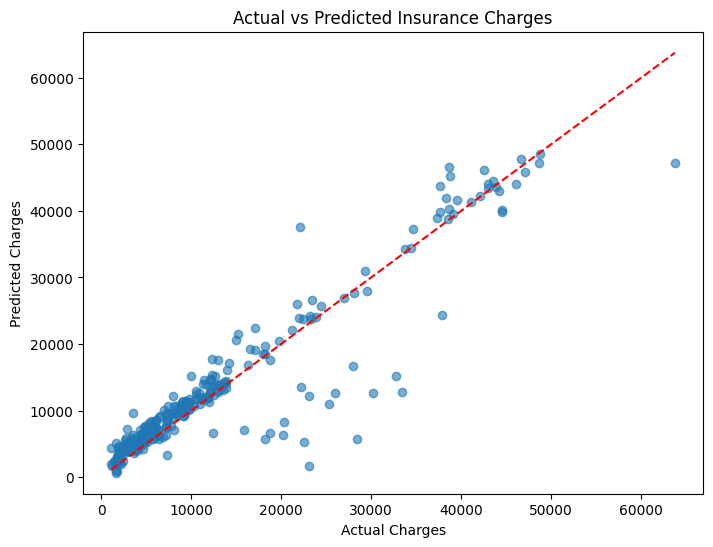

In [10]:
# Scatter Plot: Actual vs Predicted Charges

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()

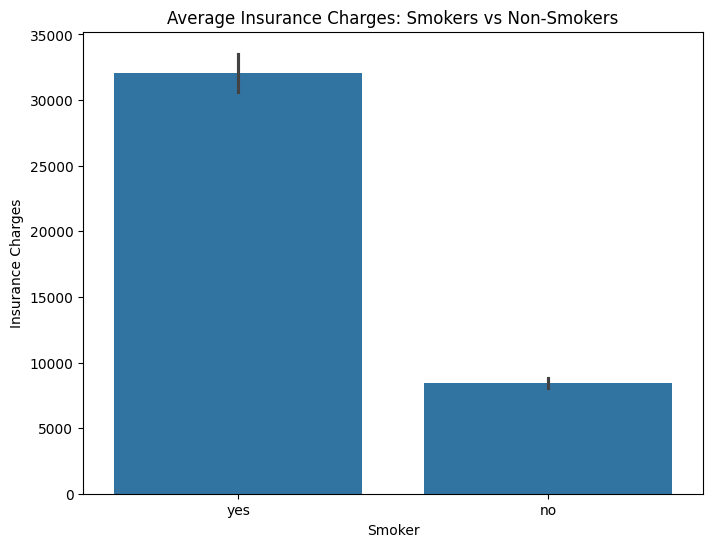

In [11]:
# Smoker vs Non-Smoker Insurance Charges

plt.figure(figsize=(8,6))

sns.barplot(
    x="smoker",
    y="charges",
    data=df
)

plt.title("Average Insurance Charges: Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")

plt.show()

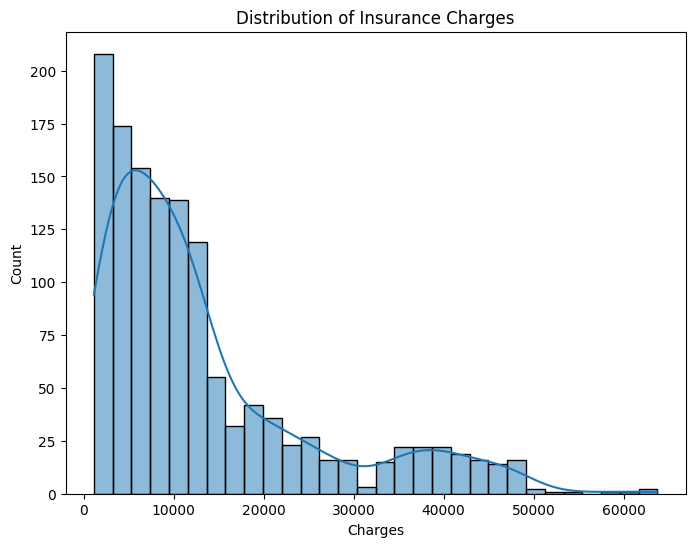

In [12]:
# Distribution of Insurance Charges

plt.figure(figsize=(8,6))

sns.histplot(df["charges"], bins=30, kde=True)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")

plt.show()